# Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from pathlib import Path
import matplotlib.ticker as mticker

plt.rcParams.update({"font.family": "palatino", "figure.dpi": 300})

# Load Data

In [2]:
path = Path("Data/zillow_foreco_cross_sectional_base_and_reconciled.parquet")
forecast = pd.read_parquet(path)
forecast.head()

,unique_id,ds,cutoff,y,forecast,model,type,hierarchy_level
0,US,2021-04-30,2021-03-31,431346.0,365300.133000,AutoARIMA__base,out_sample,0
1,US,2021-05-31,2021-03-31,434753.0,368583.919373,AutoARIMA__base,out_sample,0
2,US,2021-06-30,2021-03-31,508881.0,448254.840018,AutoARIMA__base,out_sample,0
3,US,2021-07-31,2021-03-31,476737.0,465181.568488,AutoARIMA__base,out_sample,0
4,US,2021-08-31,2021-03-31,468873.0,460777.883123,AutoARIMA__base,out_sample,0


## Verifications

In [3]:
print(f"Rows: {len(forecast):,}")
print(f"Columns: {forecast.shape[1]:,}")
print(f"Series: {forecast['unique_id'].nunique():,}")
print(f"Model-method combinations: {forecast['model'].nunique():,}")
print(f"Cutoffs: {forecast['cutoff'].nunique():,}")
print(f"Date range: {forecast['ds'].min()} to {forecast['ds'].max()}")
print(f"Cutoff range: {forecast['cutoff'].min()} to {forecast['cutoff'].max()}")

Rows: 2,793,000
Columns: 8
Series: 350
Model-method combinations: 133
Cutoffs: 5
Date range: 2021-04-30 to 2026-03-31
Cutoff range: 2021-03-31 to 2025-03-31


In [4]:
forecast.groupby("hierarchy_level").agg(n_series=("unique_id", "nunique"), rows=("unique_id", "size")).reset_index()

,hierarchy_level,n_series,rows
0,0,1,7980
1,1,49,391020
2,2,300,2394000


## Reconciliation method abbreviations

The forecast configurations are encoded as `model__method`. 

| Original code | Short label | Meaning |
|---|---:|---|
| `base` | Base | Original unreconciled forecast. |
| `csbu` | BU | Bottom-up reconciliation. Bottom-level forecasts are aggregated upward. |
| `csbu_sntz` | BU-SNTZ | Bottom-up reconciliation after setting negative bottom-level forecasts to zero. |
| `cstd_gsa` | TD-GSA | Top-down reconciliation using average historical proportions. |
| `cstd_gsf` | TD-GSF | Top-down reconciliation using proportions of historical averages. |
| `csmo_gsa` | MO-GSA | Middle-out reconciliation from the state level using average historical proportions. |
| `csmo_gsf` | MO-GSF | Middle-out reconciliation from the state level using proportions of historical averages. |
| `csrec_ols` | OLS | Least-squares reconciliation without covariance weighting. |
| `csrec_wls` | WLS | Weighted least-squares reconciliation. |
| `csrec_shr` | SHR | Shrinkage covariance-based reconciliation using in-sample residuals. |
| `cslcc_ols` | LCC-OLS | Level-conditional coherent reconciliation without covariance weighting. |
| `cslcc_wls` | LCC-WLS | Level-conditional coherent reconciliation with weighted least squares. |
| `cslcc_shr` | LCC-SHR | Level-conditional coherent reconciliation with shrinkage covariance estimation. |

In [5]:
method_map = {
    "base": "Base",
    "csbu": "BU",
    "csbu_sntz": "BU-SNTZ",
    "cstd_gsa": "TD-GSA",
    "cstd_gsf": "TD-GSF",
    "csmo_gsa": "MO-GSA",
    "csmo_gsf": "MO-GSF",
    "csrec_ols": "OLS",
    "csrec_wls": "WLS",
    "csrec_shr": "SHR",
    "cslcc_ols": "LCC-OLS",
    "cslcc_wls": "LCC-WLS",
    "cslcc_shr": "LCC-SHR"
}

forecast = forecast.copy()
forecast["ds"] = pd.to_datetime(forecast["ds"])
forecast["cutoff"] = pd.to_datetime(forecast["cutoff"])
forecast["y"] = forecast["y"].astype(float)
forecast["forecast"] = forecast["forecast"].astype(float)

forecast[["model_name", "method"]] = forecast["model"].str.rsplit("__", n=1, expand=True)
forecast["method"] = forecast["method"].map(method_map).fillna(forecast["method"])

forecast["forecast"] = forecast["forecast"].clip(lower=0)
forecast["squared_error"] = (forecast["forecast"] - forecast["y"]) ** 2

forecast.head()

,unique_id,ds,cutoff,y,forecast,model,type,hierarchy_level,model_name,method,squared_error
0,US,2021-04-30,2021-03-31,431346.0,365300.133000,AutoARIMA__base,out_sample,0,AutoARIMA,Base,4.362057e+09
1,US,2021-05-31,2021-03-31,434753.0,368583.919373,AutoARIMA__base,out_sample,0,AutoARIMA,Base,4.378347e+09
2,US,2021-06-30,2021-03-31,508881.0,448254.840018,AutoARIMA__base,out_sample,0,AutoARIMA,Base,3.675531e+09
3,US,2021-07-31,2021-03-31,476737.0,465181.568488,AutoARIMA__base,out_sample,0,AutoARIMA,Base,1.335280e+08
4,US,2021-08-31,2021-03-31,468873.0,460777.883123,AutoARIMA__base,out_sample,0,AutoARIMA,Base,6.553092e+07


# Error metric (NRMSE)

In [6]:
# NRMSE per "model", "method", "unique_id", "hierarchy_level", "cutoff"
nrmse_by_series = (forecast
    .groupby(["model_name", "method", "unique_id", "hierarchy_level", "cutoff"], as_index=False)
    .agg(mse=("squared_error", "mean"), mean_y=("y", "mean")))

nrmse_by_series["nrmse"] = np.where(nrmse_by_series["mean_y"] != 0, np.sqrt(nrmse_by_series["mse"]) / nrmse_by_series["mean_y"], np.nan)

# NRMSE per "model", "method", "hierarchy_level", "cutoff"
nrmse_by_cutoff = (nrmse_by_series
    .groupby(["model_name", "method", "hierarchy_level", "cutoff"], as_index=False)
    .agg(nrmse=("nrmse", "mean")))

# Global error

In [7]:
global_nrmse = (nrmse_by_cutoff
    .groupby(["model_name", "method"], as_index=False)
    .agg(nrmse=("nrmse", "mean"))
    .sort_values("nrmse"))

global_nrmse["nrmse"] = global_nrmse["nrmse"].round(4)

global_table = (global_nrmse
    .pivot(index="model_name", columns="method", values="nrmse")
    .reset_index())
global_table

method,model_name,BU,BU-SNTZ,Base,LCC-OLS,LCC-SHR,MO-GSA,MO-GSF,OLS,SHR,TD-GSA,TD-GSF
0,AutoARIMA,0.1733,0.1733,0.1706,0.1740,0.1682,0.1802,0.1796,0.2287,0.1957,0.1918,0.1889
1,AutoARIMAX,0.1451,0.1451,0.1544,0.1566,0.1493,0.1556,0.1550,0.2303,0.1669,0.1988,0.1964
2,CatBoost,0.1887,0.1887,0.1797,0.1820,0.1731,0.2016,0.2016,0.2893,0.1811,0.1913,0.1894
3,GRU,0.2355,0.2355,0.2392,0.2407,0.2377,0.2376,0.2372,0.2656,0.2362,0.2630,0.2617
4,HoltWinters,0.1459,0.1459,0.1469,0.1459,0.1439,0.1529,0.1524,0.1883,0.1530,0.1838,0.1806
5,KAN,0.1985,0.1985,0.2061,0.2099,0.2044,0.2033,0.2027,0.2541,0.2027,0.2403,0.2392
6,LightGBM,0.2109,0.2109,0.1885,0.1887,0.1886,0.2272,0.2272,0.2975,0.2098,0.1817,0.1800
7,MFLES,0.1620,0.1620,0.1687,0.1691,0.1623,0.1708,0.1703,0.2156,0.1572,0.2066,0.2039
8,NBEATSx,0.1647,0.1647,0.1663,0.1663,0.1657,0.1702,0.1697,0.1748,0.1643,0.1994,0.1973
9,NHITS,0.1593,0.1593,0.1614,0.1614,0.1606,0.1654,0.1648,0.1704,0.1597,0.1955,0.1933


## Global comparison | Base models vs Seasonal Naive

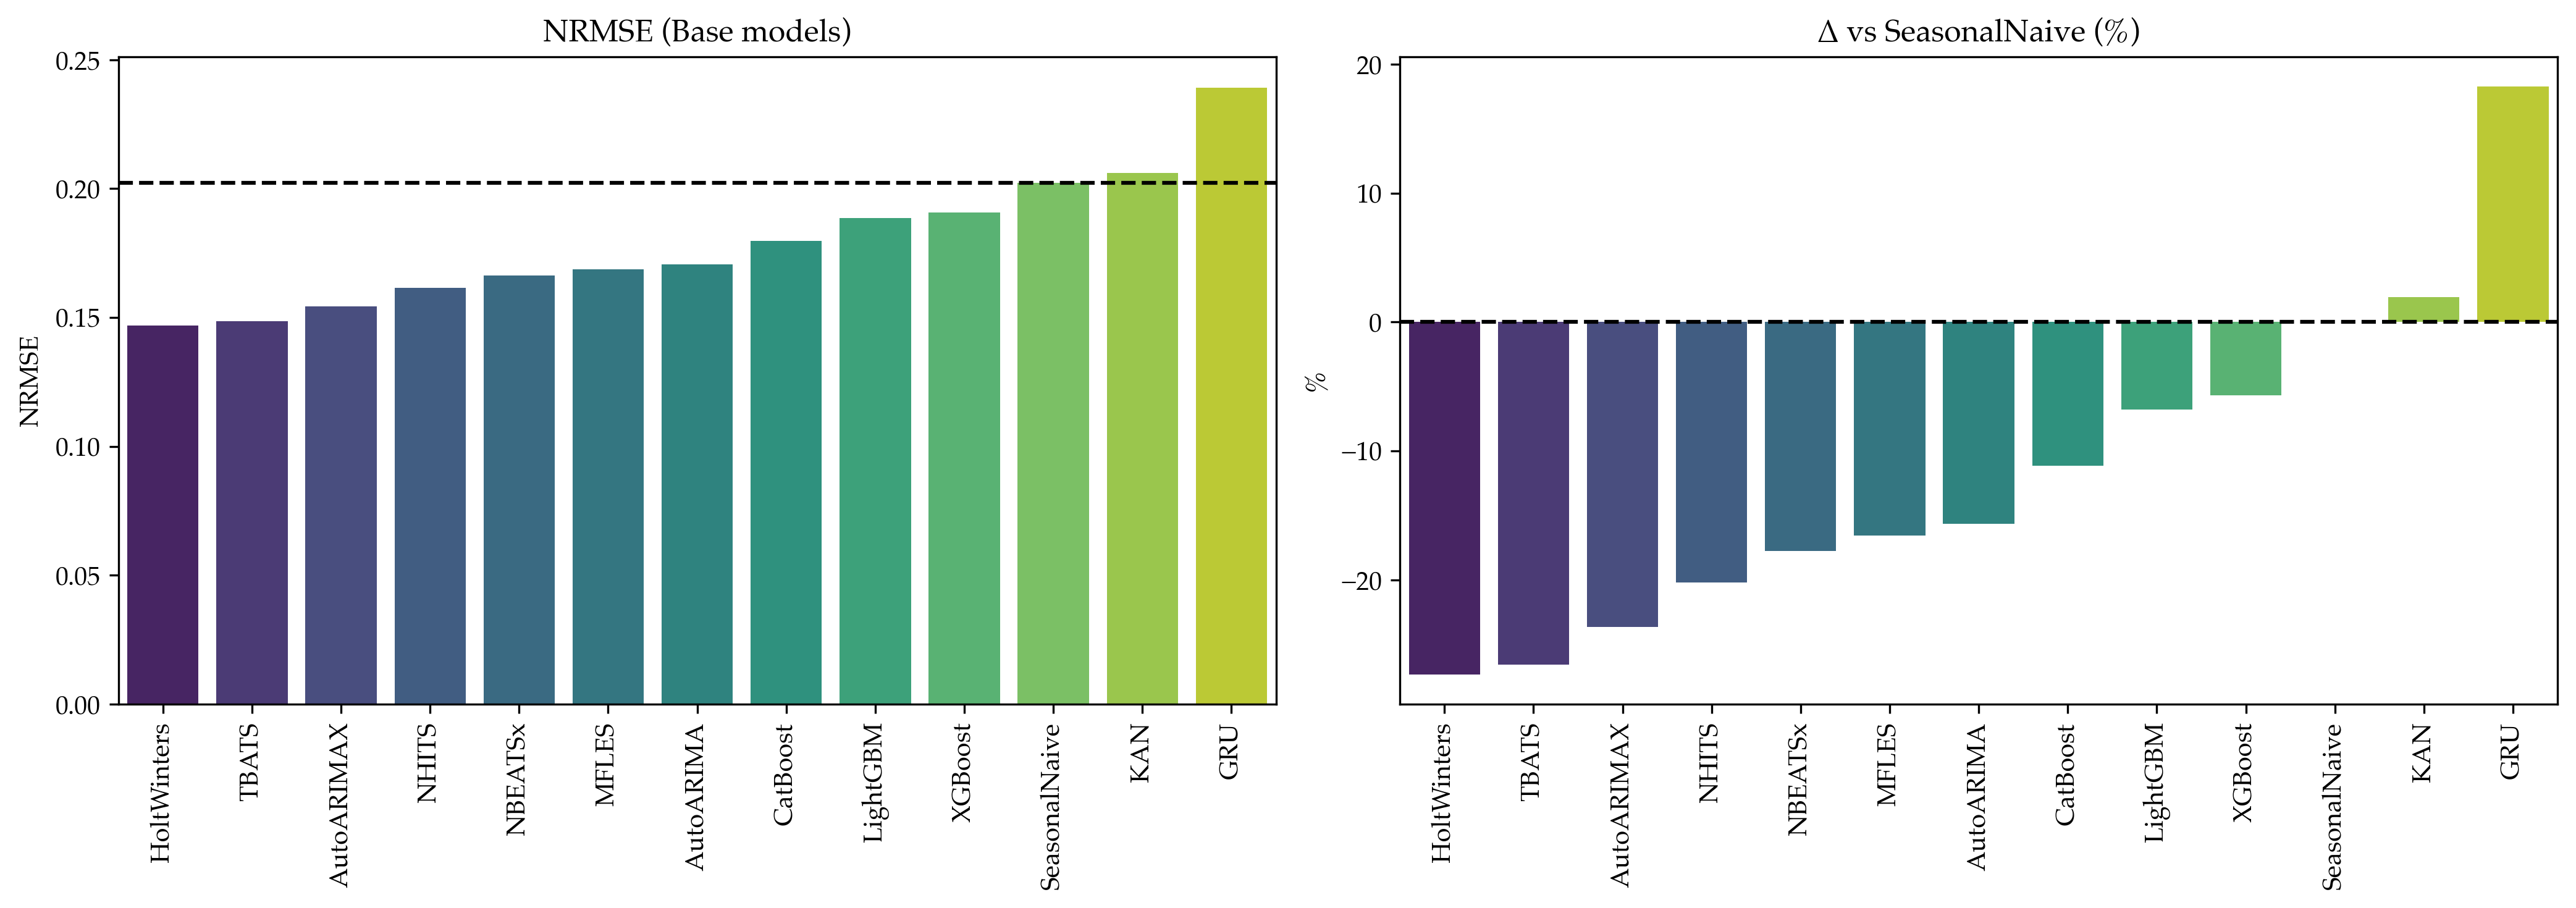

In [8]:
base = global_nrmse.query("method == 'Base'").sort_values("nrmse").copy()

sn = base.loc[base["model_name"] == "SeasonalNaive", "nrmse"].iloc[0]
base["diff_pct"] = 100 * (base["nrmse"] - sn) / sn

palette = sns.color_palette("viridis", n_colors=len(base))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=base, x="model_name", y="nrmse", hue="model_name", palette=palette, legend=False, ax=ax[0])
ax[0].axhline(sn, ls="--", c="black")
ax[0].set(title="NRMSE (Base models)", xlabel="", ylabel="NRMSE")
ax[0].tick_params(axis="x", rotation=90)

sns.barplot(data=base.sort_values("diff_pct"), x="model_name", y="diff_pct",
            hue="model_name", palette=palette, legend=False, ax=ax[1])
ax[1].axhline(0, ls="--", c="black")
ax[1].set(title="Δ vs SeasonalNaive (%)", xlabel="", ylabel="%")
ax[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

## Error reductions after applying reconciliation 

In [9]:
base = (global_nrmse.query("method == 'Base'")[["model_name", "nrmse"]].rename(columns={"nrmse": "base_nrmse"}))

global_change = global_nrmse.merge(base, on="model_name", how="left")

global_change["change_pct"] = 100 * (global_change["nrmse"] - global_change["base_nrmse"]) / global_change["base_nrmse"]
global_change = global_change.sort_values(["model_name", "nrmse"])
global_change["change_pct"] = global_change["change_pct"].round(2)

change_table = (global_change
    .query("method != 'Base'")
    .pivot(index="model_name", columns="method", values="change_pct")
    .reset_index())
change_table

method,model_name,BU,BU-SNTZ,LCC-OLS,LCC-SHR,MO-GSA,MO-GSF,OLS,SHR,TD-GSA,TD-GSF
0,AutoARIMA,1.58,1.58,1.99,-1.41,5.63,5.28,34.06,14.71,12.43,10.73
1,AutoARIMAX,-6.02,-6.02,1.42,-3.30,0.78,0.39,49.16,8.10,28.76,27.20
2,CatBoost,5.01,5.01,1.28,-3.67,12.19,12.19,60.99,0.78,6.46,5.40
3,GRU,-1.55,-1.55,0.63,-0.63,-0.67,-0.84,11.04,-1.25,9.95,9.41
4,HoltWinters,-0.68,-0.68,-0.68,-2.04,4.08,3.74,28.18,4.15,25.12,22.94
5,KAN,-3.69,-3.69,1.84,-0.82,-1.36,-1.65,23.29,-1.65,16.59,16.06
6,LightGBM,11.88,11.88,0.11,0.05,20.53,20.53,57.82,11.30,-3.61,-4.51
7,MFLES,-3.97,-3.97,0.24,-3.79,1.24,0.95,27.80,-6.82,22.47,20.87
8,NBEATSx,-0.96,-0.96,0.00,-0.36,2.35,2.04,5.11,-1.20,19.90,18.64
9,NHITS,-1.30,-1.30,0.00,-0.50,2.48,2.11,5.58,-1.05,21.13,19.76


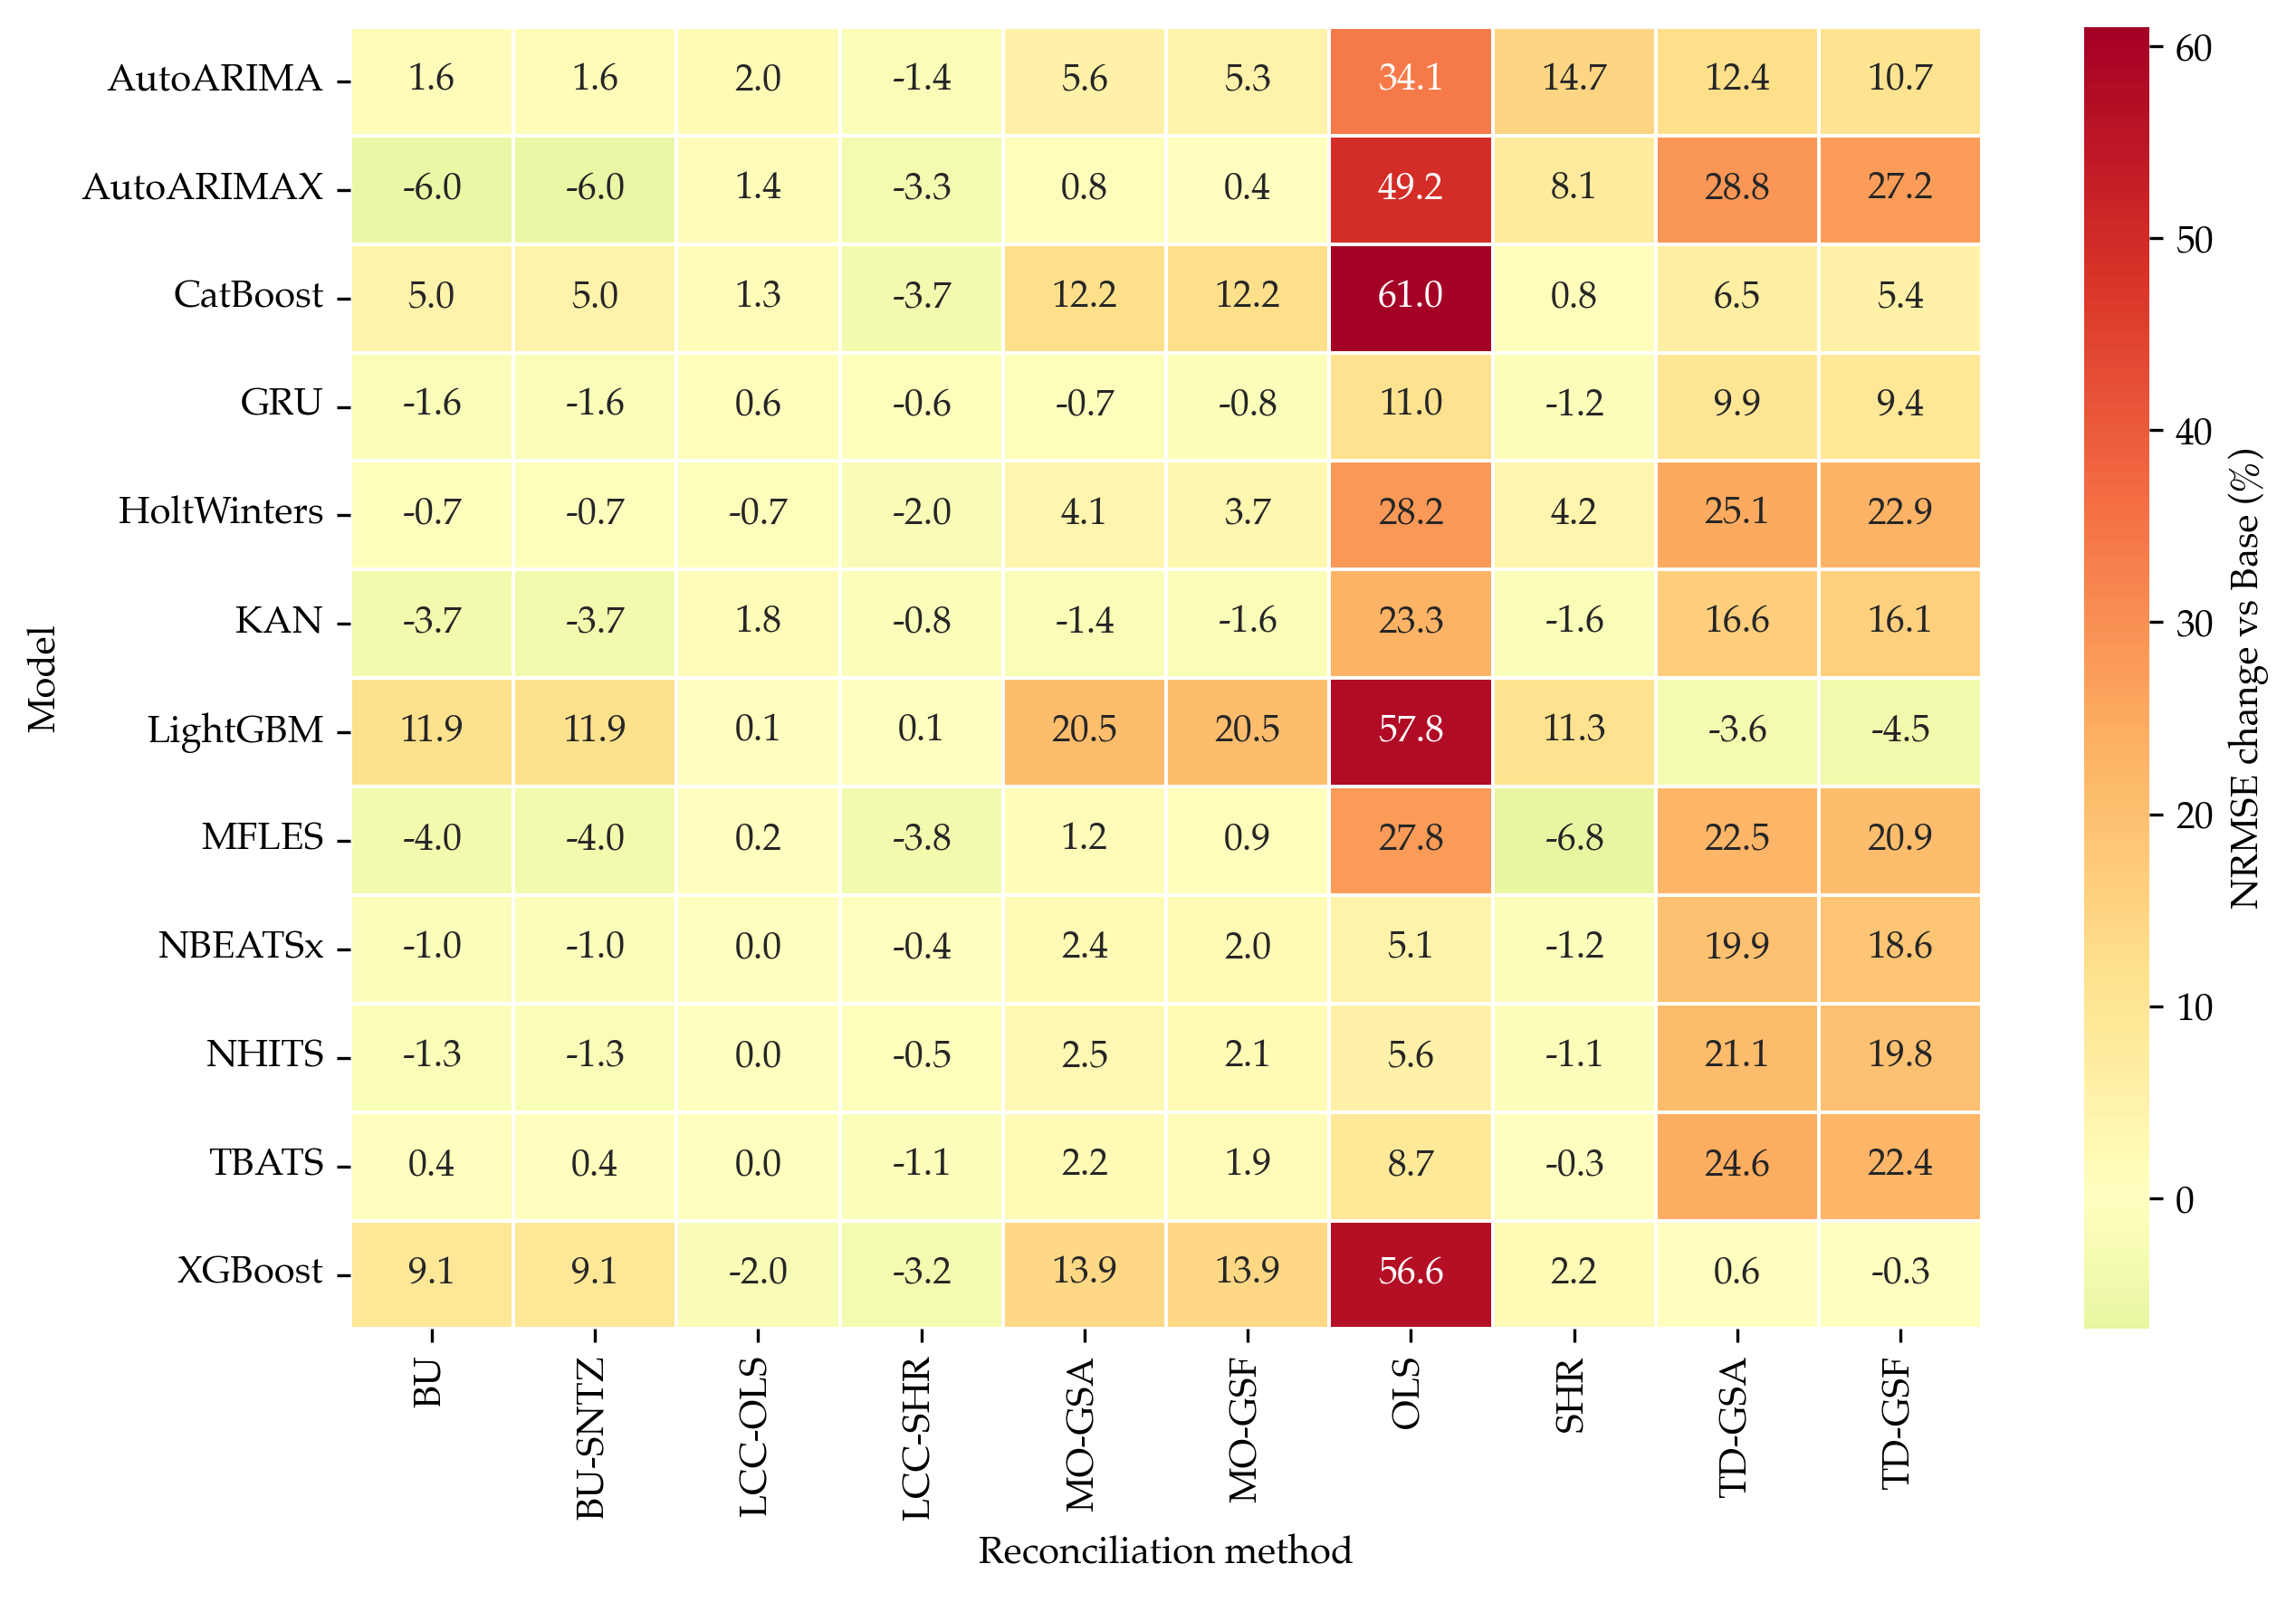

In [10]:
heatmap_data = change_table.set_index("model_name")

plt.figure(figsize=(9, 6))
sns.heatmap(heatmap_data, cmap="RdYlGn_r", center=0, annot=True, fmt=".1f", linewidths=0.5, cbar_kws={"label": "NRMSE change vs Base (%)"})
plt.xlabel("Reconciliation method")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

# Error by hierarchical level

In [11]:
level_nrmse = (nrmse_by_cutoff
    .groupby(["hierarchy_level", "model_name", "method"], as_index=False)
    .agg(nrmse=("nrmse", "mean"))
    .sort_values(["hierarchy_level", "nrmse"]))

level_nrmse["nrmse"] = level_nrmse["nrmse"].round(4)

level_table = (level_nrmse.pivot_table(
        index=["hierarchy_level", "model_name"],
        columns="method",
        values="nrmse")
    .reset_index())
level_table

method,hierarchy_level,model_name,BU,BU-SNTZ,Base,LCC-OLS,LCC-SHR,MO-GSA,MO-GSF,OLS,SHR,TD-GSA,TD-GSF
0,0,AutoARIMA,0.1501,0.1501,0.1371,0.1450,0.1450,0.1554,0.1554,0.1372,0.1851,0.1371,0.1371
1,0,AutoARIMAX,0.1263,0.1263,0.1519,0.1335,0.1335,0.1302,0.1302,0.1511,0.1570,0.1519,0.1519
2,0,CatBoost,0.1724,0.1724,0.1392,0.1519,0.1519,0.1784,0.1784,0.1387,0.1584,0.1392,0.1392
3,0,GRU,0.2210,0.2210,0.2291,0.2238,0.2238,0.2220,0.2220,0.2289,0.2211,0.2291,0.2291
4,0,HoltWinters,0.1258,0.1258,0.1271,0.1239,0.1239,0.1237,0.1237,0.1268,0.1335,0.1271,0.1271
5,0,KAN,0.1843,0.1843,0.2041,0.1911,0.1911,0.1864,0.1864,0.2036,0.1892,0.2041,0.2041
6,0,LightGBM,0.1966,0.1966,0.1236,0.1680,0.1680,0.2086,0.2086,0.1243,0.1951,0.1236,0.1236
7,0,MFLES,0.1379,0.1379,0.1528,0.1411,0.1411,0.1400,0.1400,0.1522,0.1426,0.1528,0.1528
8,0,NBEATSx,0.1489,0.1489,0.1520,0.1500,0.1500,0.1496,0.1496,0.1519,0.1485,0.1520,0.1520
9,0,NHITS,0.1421,0.1421,0.1470,0.1441,0.1441,0.1440,0.1440,0.1469,0.1439,0.1470,0.1470


## Hierarchy level comparison Base models vs Seasonal Naive

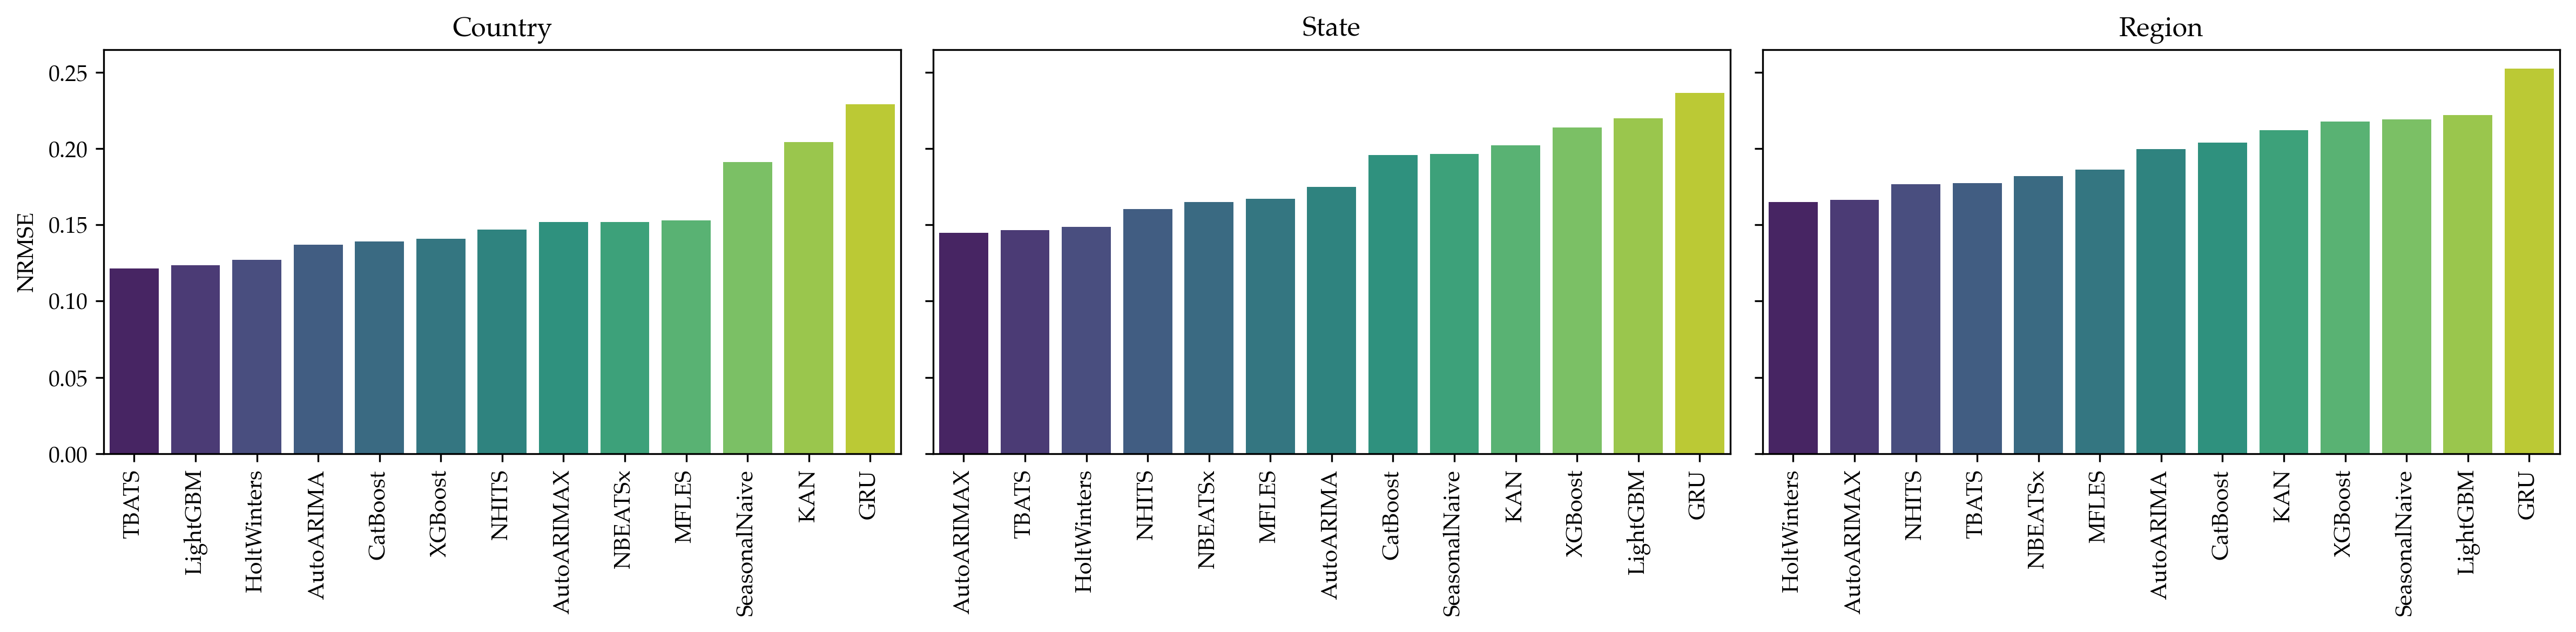

In [12]:
base = level_nrmse.query("method == 'Base'")

palette = sns.color_palette("viridis", base["model_name"].nunique())

fig, ax = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

for i, lvl in enumerate(sorted(base["hierarchy_level"].unique())):
    d = base.query("hierarchy_level == @lvl").sort_values("nrmse")
    
    sns.barplot(data=d, x="model_name", y="nrmse",
                hue="model_name", palette=palette,
                legend=False, ax=ax[i])
    
    ax[i].set(title={0: "Country", 1: "State", 2: "Region"}[lvl], xlabel="", ylabel="NRMSE" if i == 0 else "")
    ax[i].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

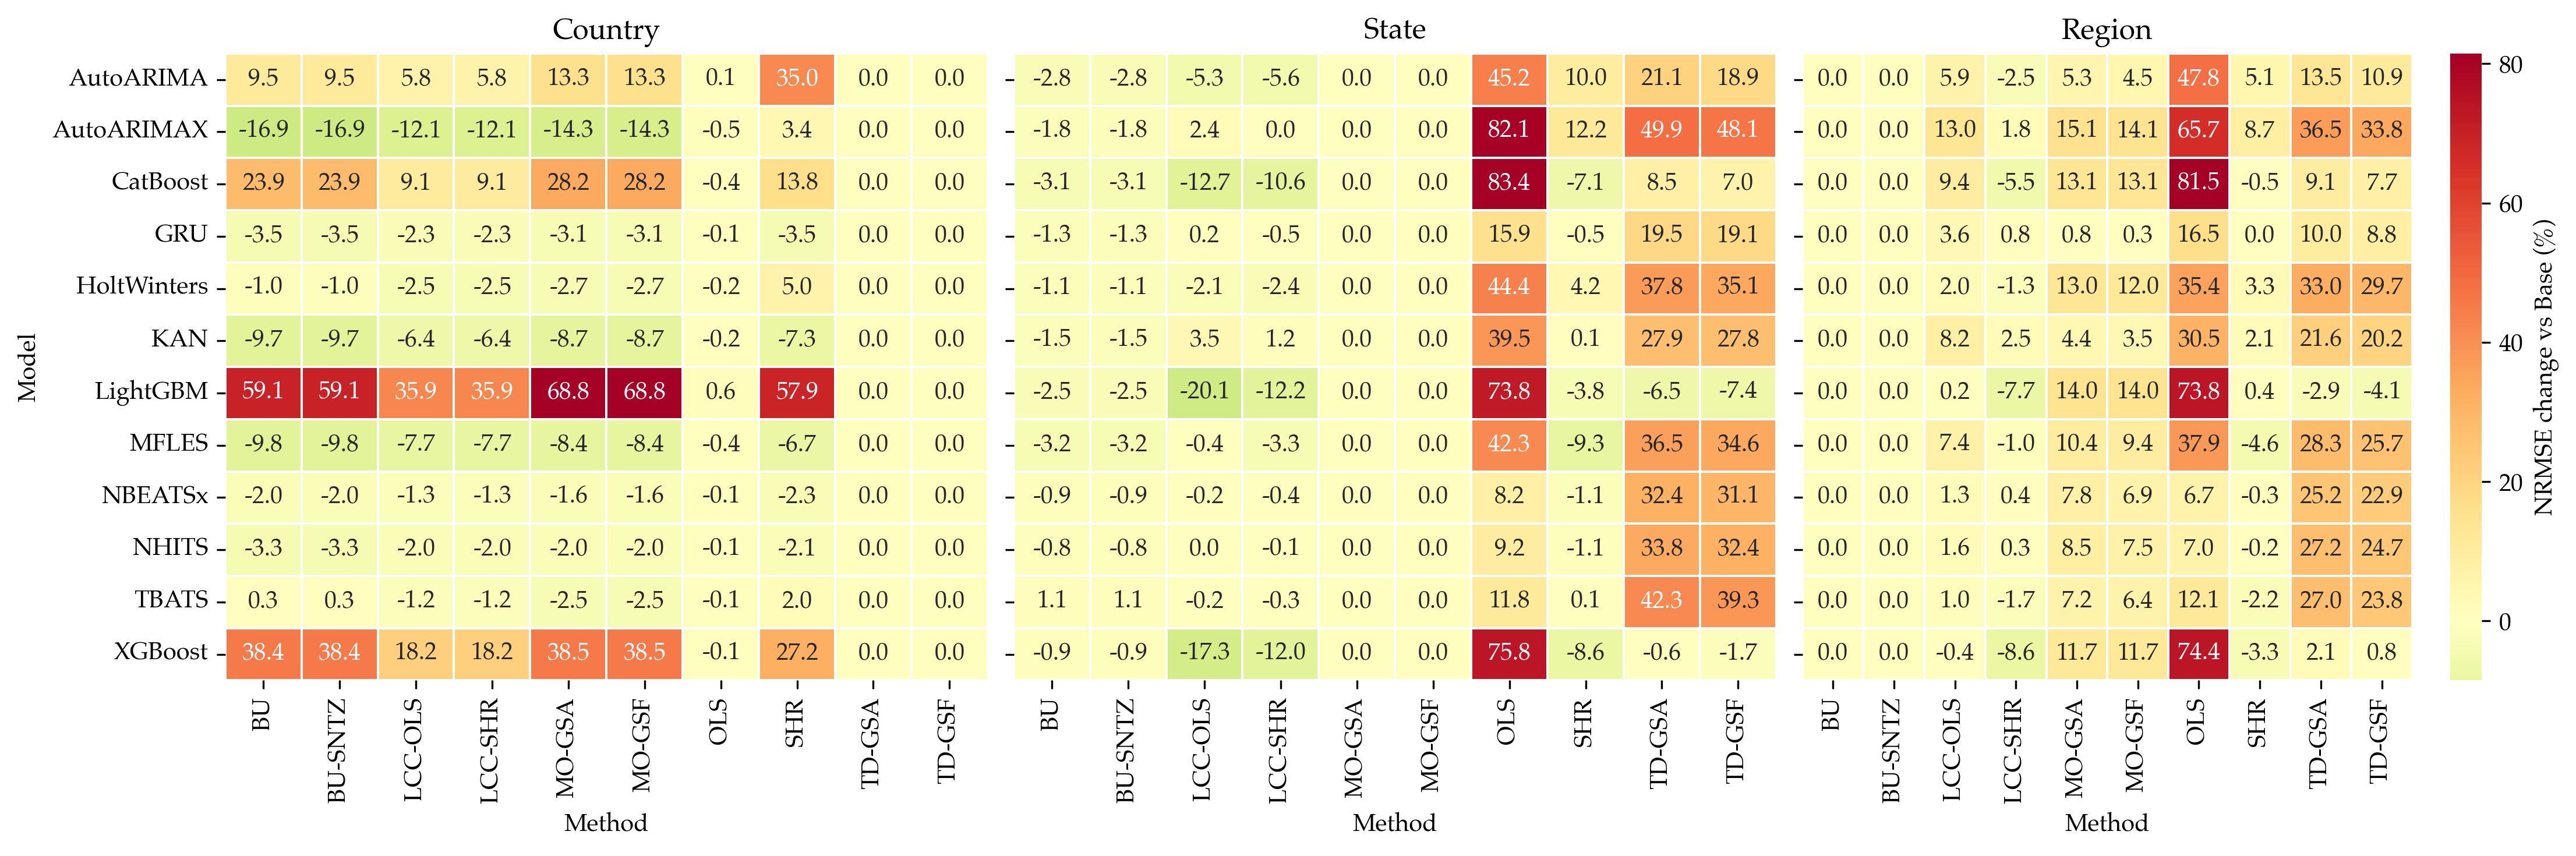

In [13]:
base_lvl = (level_nrmse.query("method == 'Base'")[["hierarchy_level", "model_name", "nrmse"]].rename(columns={"nrmse": "base_nrmse"}))
lvl_change = level_nrmse.merge(base_lvl, on=["hierarchy_level", "model_name"], how="left")
lvl_change["change_pct"] = 100 * (lvl_change["nrmse"] - lvl_change["base_nrmse"]) / lvl_change["base_nrmse"]
lvl_change["change_pct"] = lvl_change["change_pct"].round(2)

labels = {0: "Country", 1: "State", 2: "Region"}

fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for i, lvl in enumerate(sorted(lvl_change["hierarchy_level"].unique())):
    data = (lvl_change
        .query("hierarchy_level == @lvl and method != 'Base'")
        .pivot(index="model_name", columns="method", values="change_pct"))
    
    sns.heatmap(data, cmap="RdYlGn_r", center=0, annot=True, fmt=".1f", linewidths=0.5, cbar=(i == 2),  
                cbar_kws={"label": "NRMSE change vs Base (%)"} if i == 2 else None, ax=ax[i])
    
    ax[i].set_title({0: "Country", 1: "State", 2: "Region"}[lvl])
    ax[i].set_xlabel("Method")
    ax[i].set_ylabel("Model" if i == 0 else "")

plt.tight_layout()
plt.show()

## Best method per model (includes base and reconciliations)

In [14]:
best_method_by_model = (
    global_nrmse
    .sort_values(["model_name", "nrmse"])
    .groupby("model_name", as_index=False)
    .head(1)
    .sort_values("nrmse")
)

best_method_by_model

,model_name,method,nrmse
48,HoltWinters,LCC-SHR,0.1439
11,AutoARIMAX,BU,0.1451
115,TBATS,LCC-SHR,0.1469
85,MFLES,SHR,0.1572
99,NHITS,BU,0.1593
96,NBEATSx,SHR,0.1643
4,AutoARIMA,LCC-SHR,0.1682
26,CatBoost,LCC-SHR,0.1731
76,LightGBM,TD-GSF,0.1800
126,XGBoost,LCC-SHR,0.1846


## Best reductions after reconciliation

In [15]:
best_change_by_model = (
    global_change
    .query("method != 'Base'")
    .sort_values(["model_name", "change_pct"])
    .groupby("model_name", as_index=False)
    .head(1)
    .sort_values("change_pct")
)

best_change_by_model

,model_name,method,nrmse,base_nrmse,change_pct
23,MFLES,SHR,0.1572,0.1687,-6.82
1,AutoARIMAX,BU,0.1451,0.1544,-6.02
59,LightGBM,TD-GSF,0.1800,0.1885,-4.51
89,KAN,BU,0.1985,0.2061,-3.69
52,CatBoost,LCC-SHR,0.1731,0.1797,-3.67
67,XGBoost,LCC-SHR,0.1846,0.1907,-3.20
0,HoltWinters,LCC-SHR,0.1439,0.1469,-2.04
116,GRU,BU-SNTZ,0.2355,0.2392,-1.55
43,AutoARIMA,LCC-SHR,0.1682,0.1706,-1.41
24,NHITS,BU,0.1593,0.1614,-1.30


# Error distributions (best variant per model)

In [16]:
top_cfg = [
    ("HoltWinters","LCC-SHR"),
    ("AutoARIMAX","BU"),
    ("TBATS","LCC-SHR"),
    ("MFLES","SHR"),
    ("NHITS","BU"),
    ("NBEATSx","SHR"),
    ("AutoARIMA","LCC-SHR"),
    ("CatBoost","LCC-SHR"),
    ("LightGBM","TD-GSF"),
    ("XGBoost","LCC-SHR"),
    ("KAN","BU"),
    ("SeasonalNaive","Base"),
    ("GRU","BU-SNTZ")
]

top_df = nrmse_by_cutoff[
    nrmse_by_cutoff[["model_name","method"]]
    .apply(tuple, axis=1)
    .isin(top_cfg)
].copy()

top_df["config"] = top_df["model_name"] + " | " + top_df["method"]

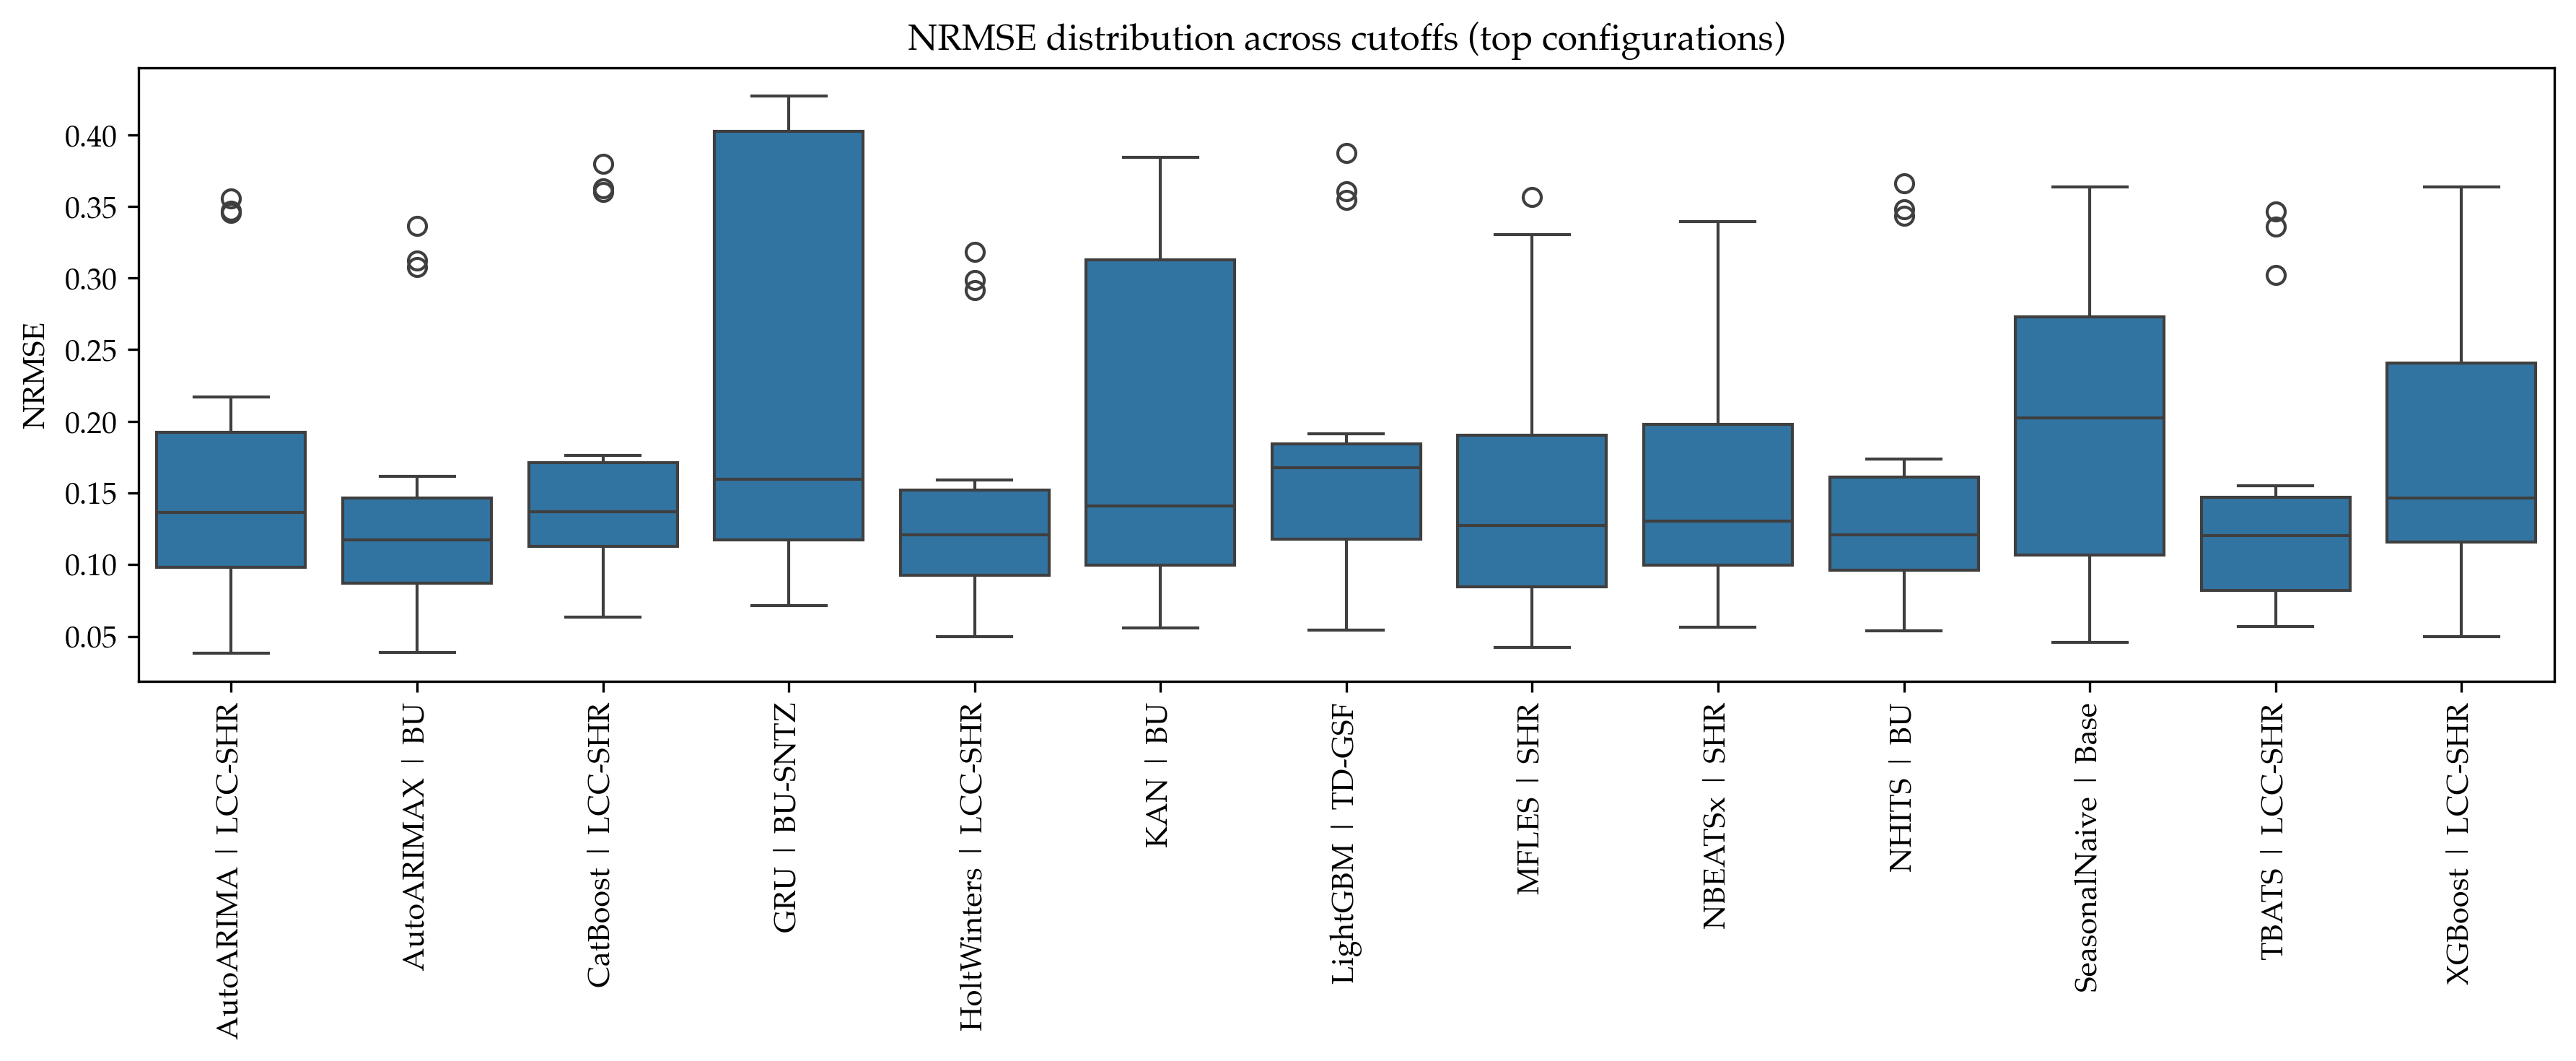

In [17]:
plt.figure(figsize=(12,5))

sns.boxplot(
    data=top_df,
    x="config",
    y="nrmse"
)

plt.xticks(rotation=90)
plt.title("NRMSE distribution across cutoffs (top configurations)")
plt.xlabel("")
plt.ylabel("NRMSE")

plt.tight_layout()
plt.show()

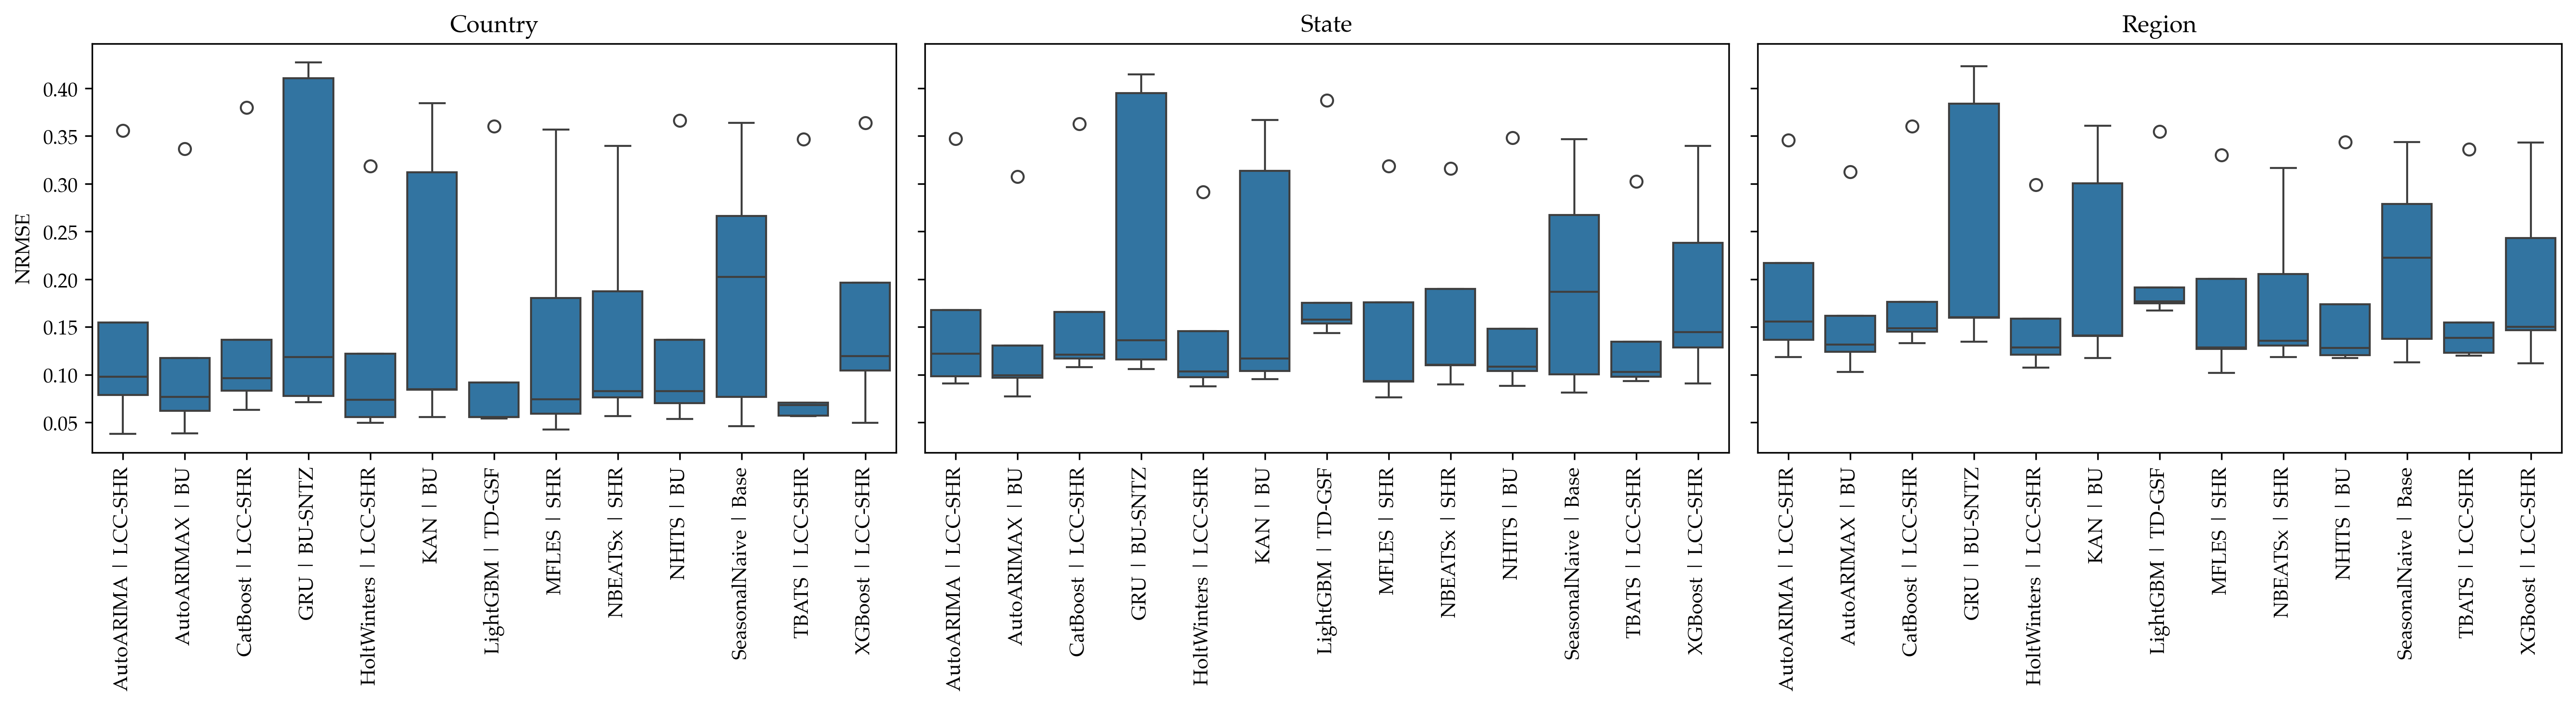

In [19]:
fig, ax = plt.subplots(1, 3, figsize=(18,5), sharey=True)

for i, lvl in enumerate(sorted(top_df["hierarchy_level"].unique())):
    d = top_df.query("hierarchy_level == @lvl")
    sns.boxplot(data=d, x="config", y="nrmse", ax=ax[i])
    ax[i].set_title({0:"Country",1:"State",2:"Region"}[lvl])
    ax[i].set_xlabel("")
    ax[i].set_ylabel("NRMSE" if i == 0 else "")
    ax[i].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

## Forecast visualization

We visualize the **top 5 configurations with the lowest global NRMSE**.

To ensure a fair comparison, we plot a single hierarchical branch:- Level 0: Country (e.g., `US`)- Level 1: State from that country (e.g., `US|NY`)- Level 2: Region from that state (e.g., `US|NY|...`)

In [20]:
top5 = best_method_by_model.head(5).copy()

df_plot = forecast.merge(top5[["model_name","method"]], on=["model_name","method"], how="inner")
df_plot["ds"] = pd.to_datetime(df_plot["ds"])
df_plot["label"] = df_plot["model_name"] + " (" + df_plot["method"] + ")"

lvl0_id = df_plot.query("hierarchy_level == 0")["unique_id"].iloc[0]          # ej: US
lvl1_id = df_plot.query("hierarchy_level == 1 and unique_id.str.startswith(@lvl0_id)")["unique_id"].iloc[0]  # ej: US|NY
lvl2_id = df_plot.query("hierarchy_level == 2 and unique_id.str.startswith(@lvl1_id)")["unique_id"].iloc[0]  # ej: US|NY|xxxx

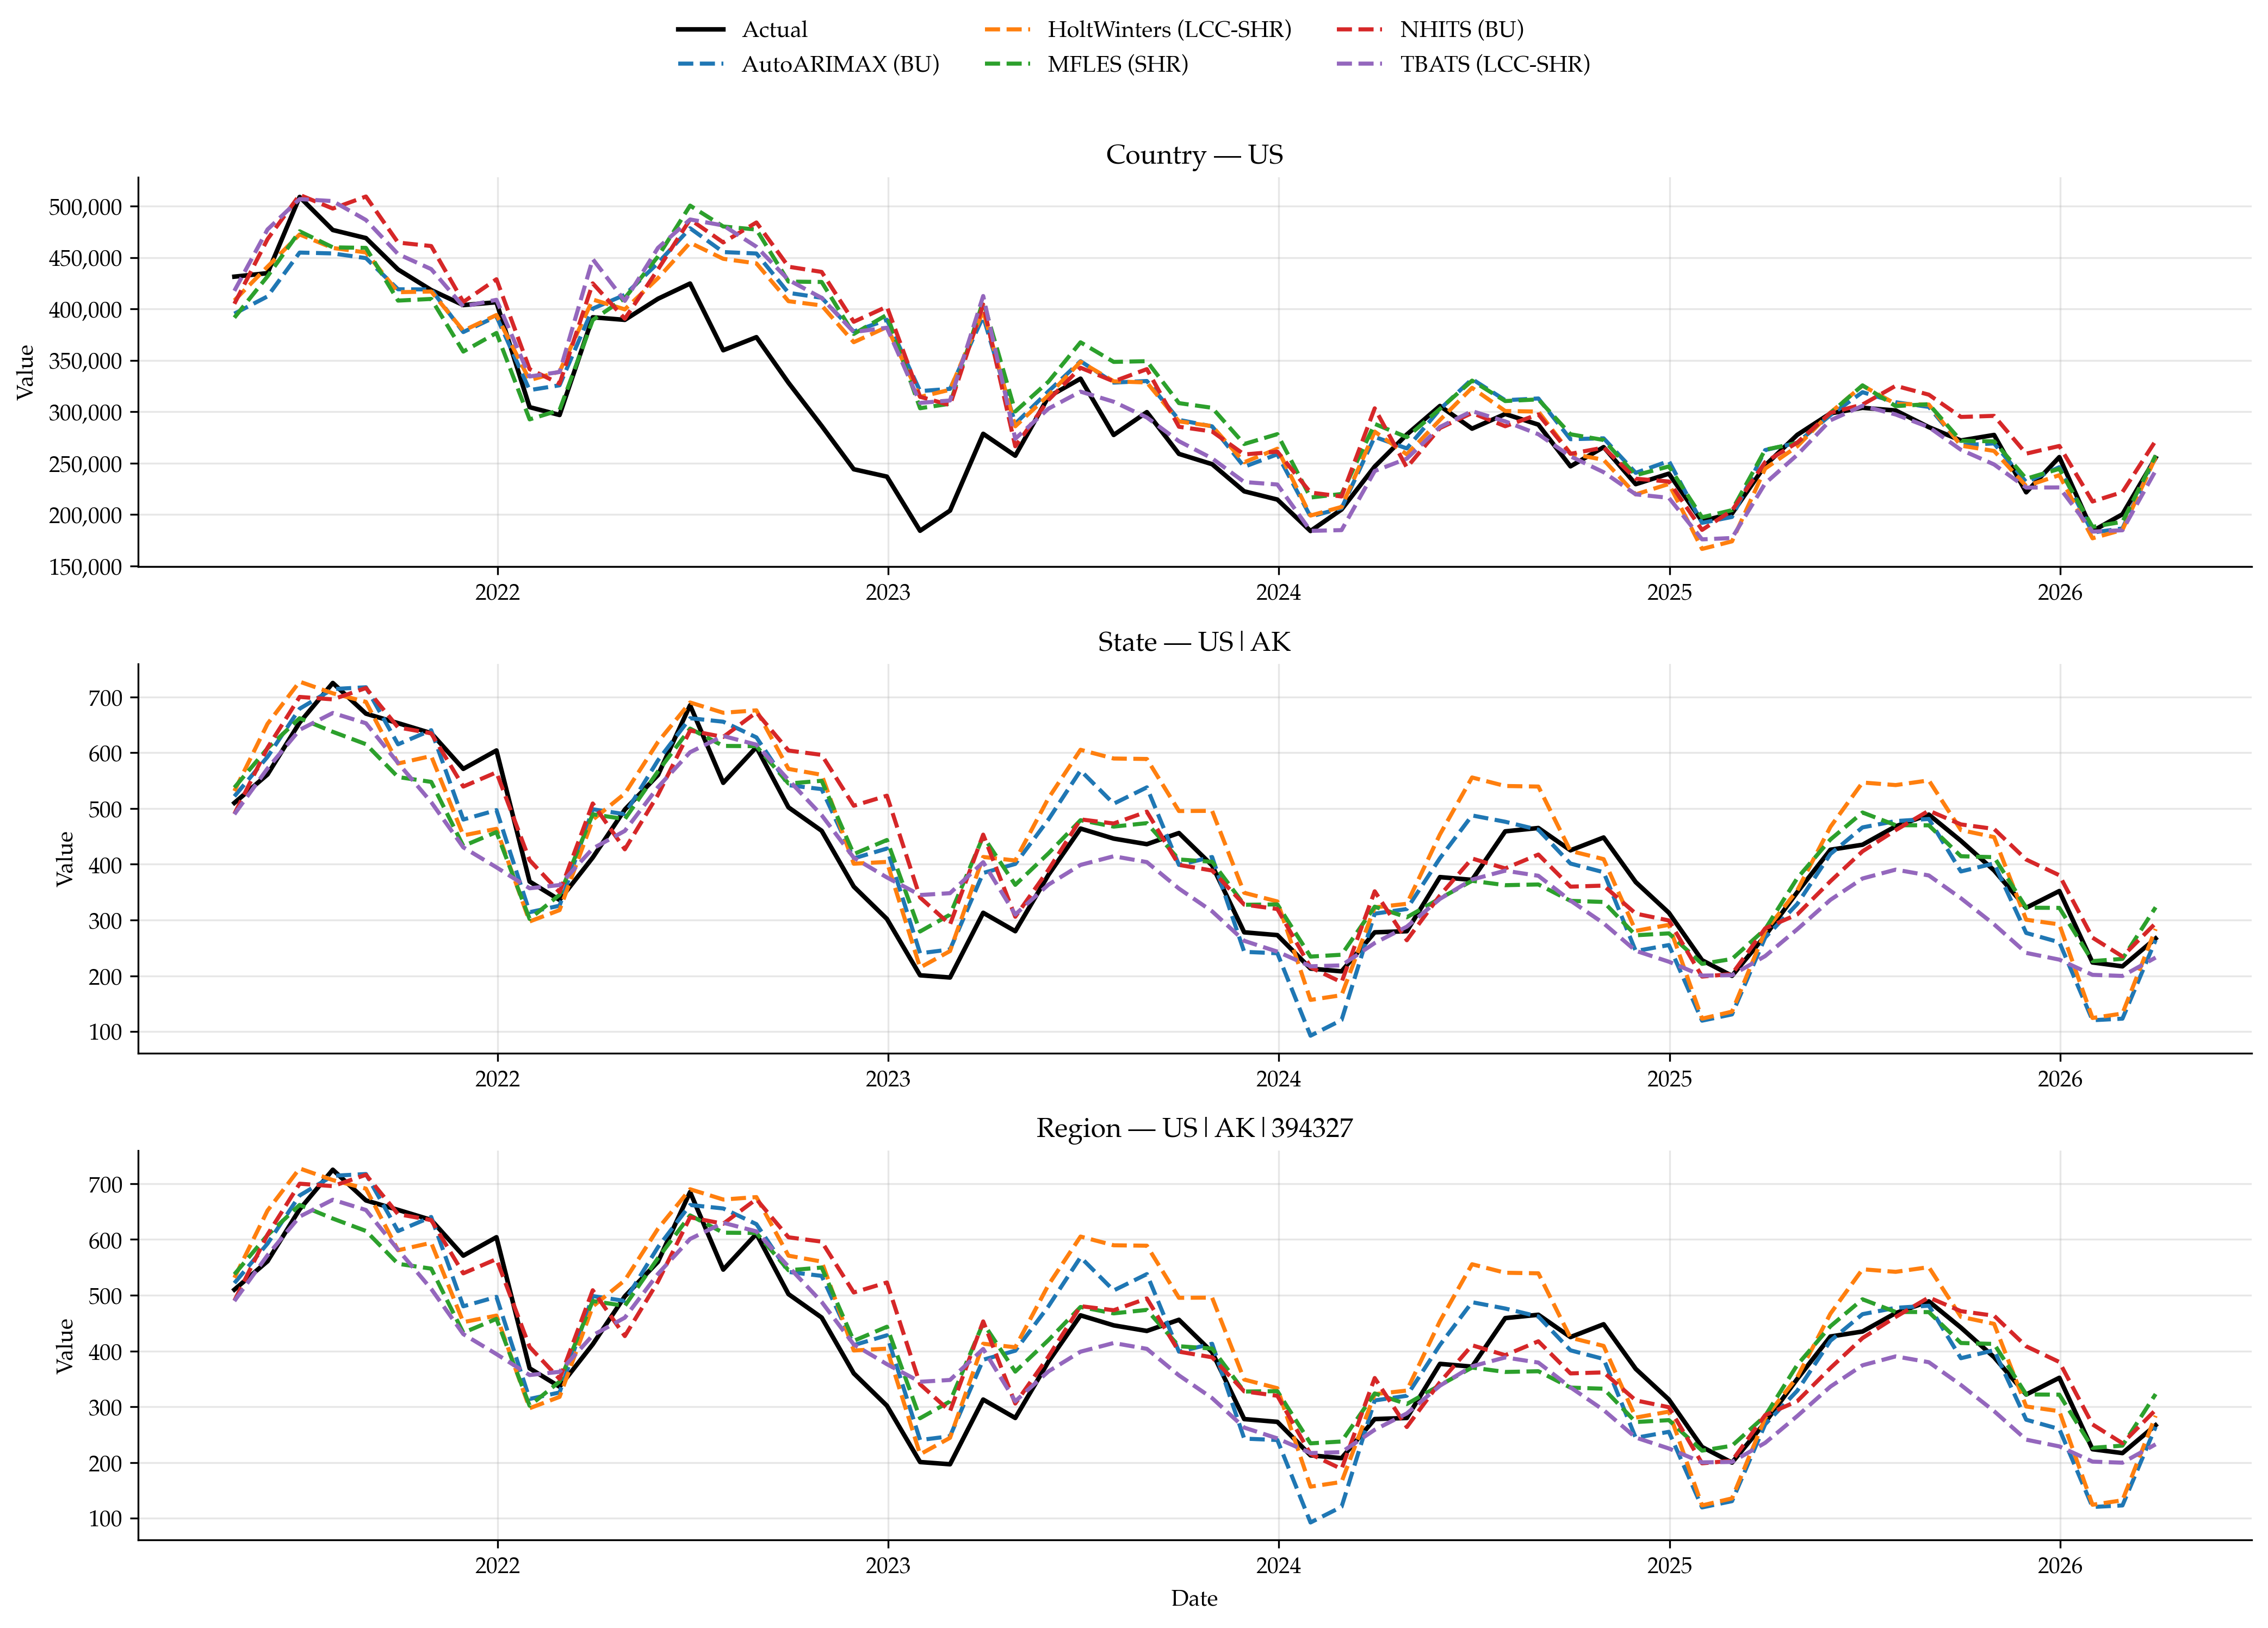

In [21]:
sample_ids = pd.DataFrame({"unique_id": [lvl0_id, lvl1_id, lvl2_id], "hierarchy_level": [0,1,2]})

level_names = {0:"Country",1:"State",2:"Region"}
palette = sns.color_palette("tab10", df_plot["label"].nunique())
color_map = dict(zip(df_plot["label"].unique(), palette))

fig, axes = plt.subplots(3,1,figsize=(14,10))

for ax, row in zip(axes, sample_ids.itertuples(index=False)):
    s = df_plot[df_plot["unique_id"] == row.unique_id]
    
    actual = s.groupby("ds",as_index=False)["y"].first()
    preds = s.groupby(["ds","label"],as_index=False)["forecast"].mean()
    
    ax.plot(actual["ds"], actual["y"], color="black", lw=2, label="Actual")
    
    for lbl, g in preds.groupby("label"):
        ax.plot(g["ds"], g["forecast"], "--", lw=1.8, color=color_map[lbl], label=lbl)
    
    ax.set_title(f"{level_names[row.hierarchy_level]} — {row.unique_id}", fontweight="bold")
    ax.set_ylabel("Value")
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
    ax.grid(alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[-1].set_xlabel("Date")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False)
plt.tight_layout(rect=[0,0,1,0.93])
plt.show()

## Bias factor analysis

We evaluate forecast bias using:

Bias factor = sum(forecast) / sum(actual)

- ≈ 1 → unbiased
- (> 1) → overforecasting
- (< 1) → underforecasting

This metric captures systematic deviation, complementing NRMSE.

In [24]:
bias = (forecast
    .groupby(["model_name","method"], as_index=False)
    .agg(sum_forecast=("forecast","sum"), sum_actual=("y","sum")))
bias["bias_pct"] = 100 * (bias["sum_forecast"] - bias["sum_actual"]) / bias["sum_actual"]
bias = bias.sort_values("bias_pct")

bias

,model_name,method,sum_forecast,sum_actual,bias_pct
28,CatBoost,MO-GSF,5.495535e+07,53903592.0,1.951179
27,CatBoost,MO-GSA,5.495535e+07,53903592.0,1.951179
26,CatBoost,LCC-SHR,5.560174e+07,53903592.0,3.150339
24,CatBoost,Base,5.560174e+07,53903592.0,3.150339
25,CatBoost,LCC-OLS,5.560344e+07,53903592.0,3.153504
...,...,...,...,...,...
59,KAN,LCC-SHR,6.275287e+07,53903592.0,16.416853
58,KAN,LCC-OLS,6.275287e+07,53903592.0,16.416853
62,KAN,OLS,6.334580e+07,53903592.0,17.516840
64,KAN,TD-GSA,6.336854e+07,53903592.0,17.559022


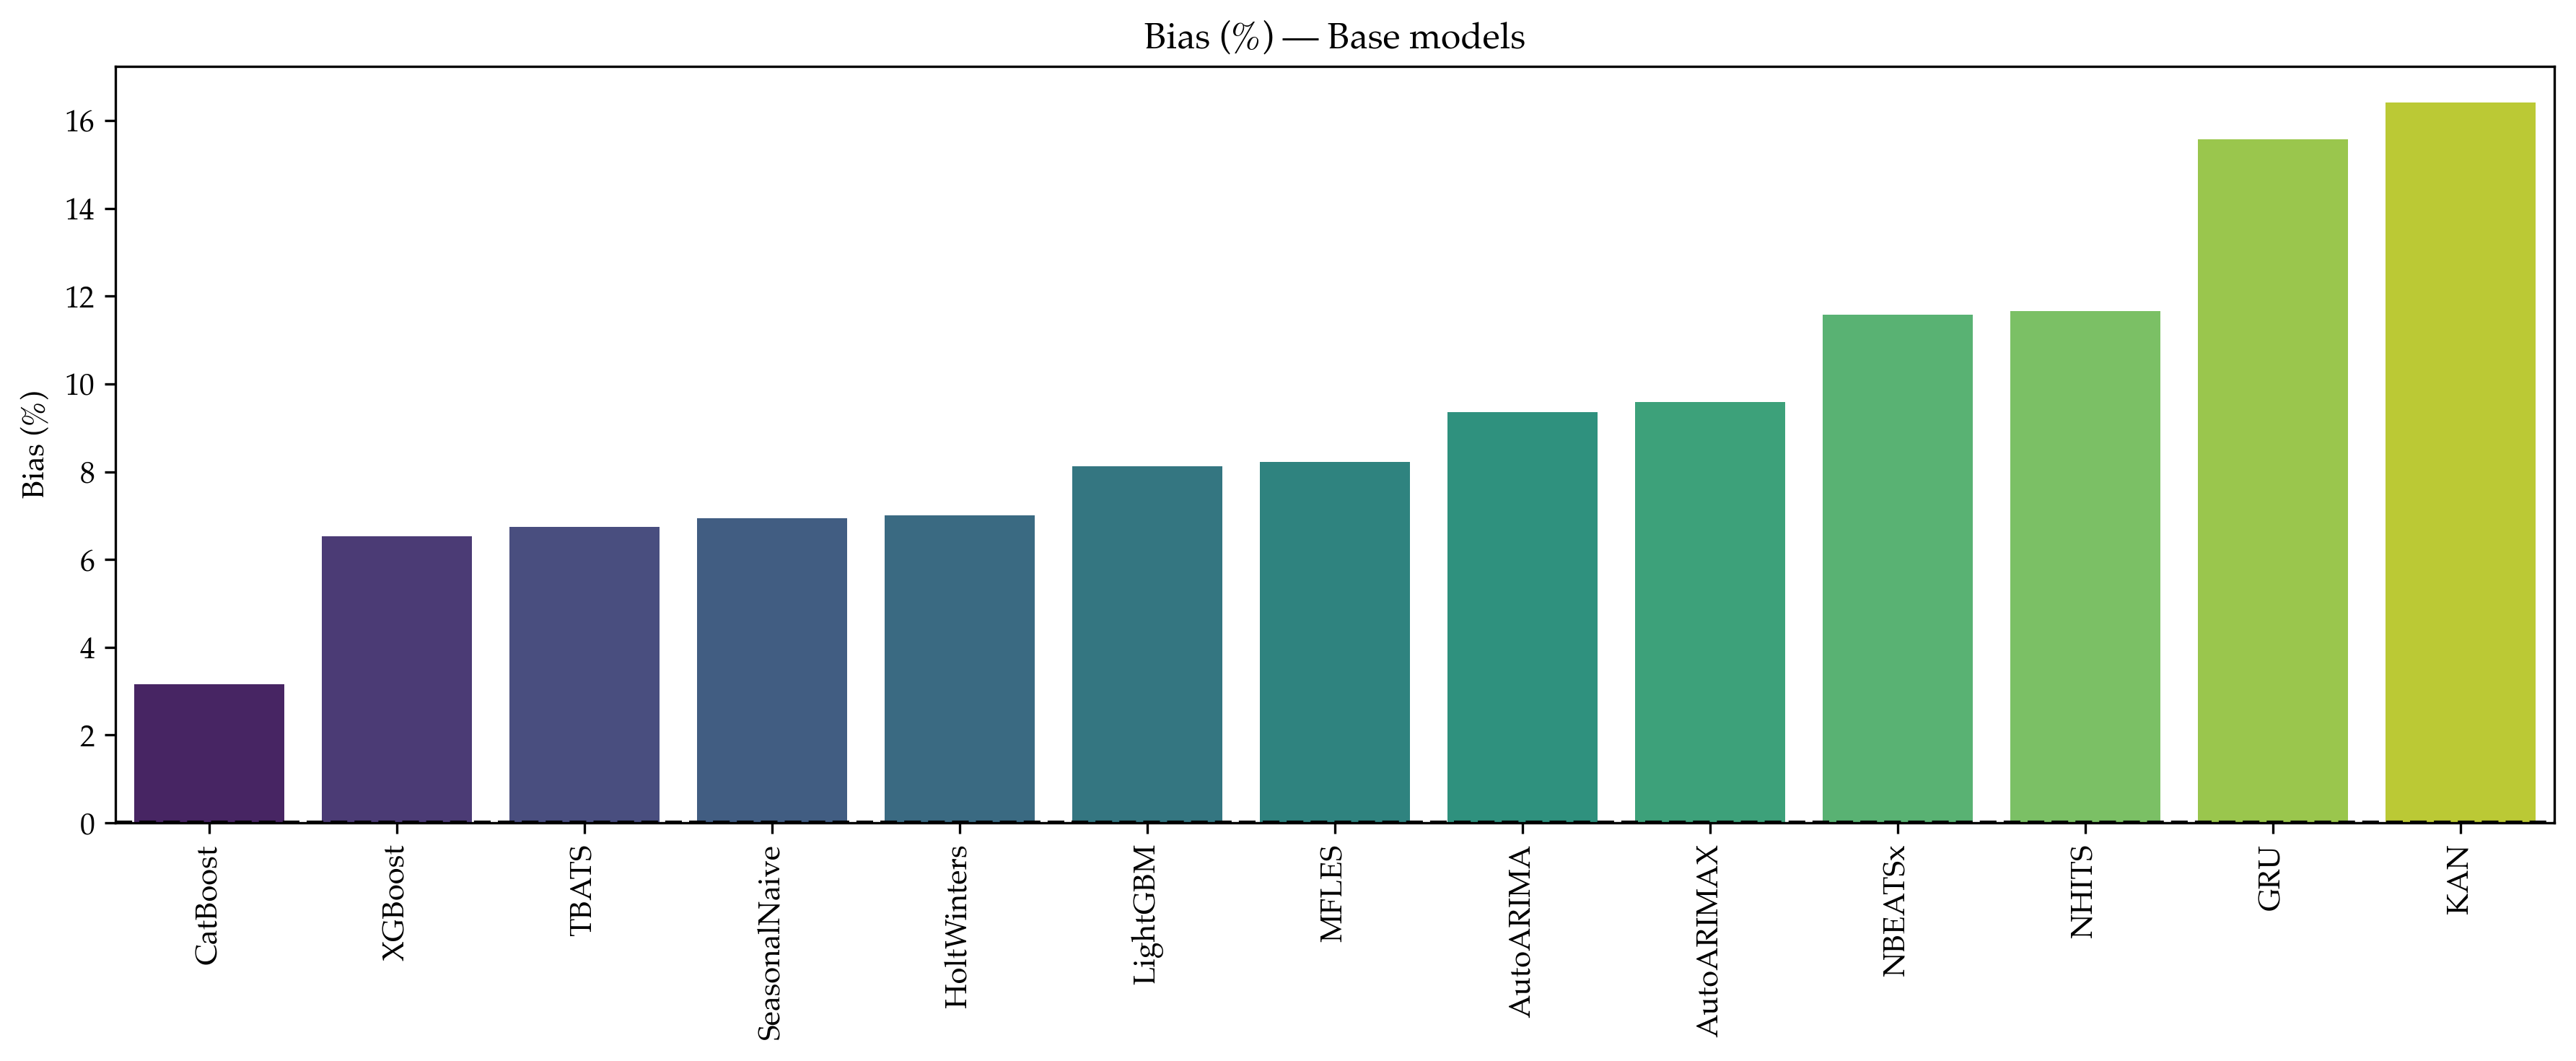

In [25]:
bias_base = bias.query("method == 'Base'").copy()

plt.figure(figsize=(12,5))
sns.barplot(data=bias_base, x="model_name", y="bias_pct", hue="model_name", palette="viridis", legend=False)
plt.axhline(0, ls="--", c="black")

plt.title("Bias (%) — Base models")
plt.xlabel("")
plt.ylabel("Bias (%)")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()